# Model Accuracy Analysis

This notebook computes and displays accuracy metrics for the Crop Recommendation and Fertilizer Recommendation models.

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import json
import os
import warnings

# Suppress version warnings for cleaner output
warnings.filterwarnings('ignore', category=UserWarning, message='.*InconsistentVersionWarning.*')

## 2. Set Paths

In [2]:
# Set paths
BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath('.')))  # Parent directory
REPORTS_DIR = os.path.join(BASE_DIR, 'reports')
MODELS_DIR = os.path.join(BASE_DIR, 'app', 'models')
DATA_DIR = os.path.join(BASE_DIR, 'archive')

print(f"Base Directory: {BASE_DIR}")
print(f"Models Directory: {MODELS_DIR}")
print(f"Data Directory: {DATA_DIR}")
print(f"Reports Directory: {REPORTS_DIR}")

Base Directory: c:\Users\rathi\Desktop\Harvestify-master
Models Directory: c:\Users\rathi\Desktop\Harvestify-master\app\models
Data Directory: c:\Users\rathi\Desktop\Harvestify-master\archive
Reports Directory: c:\Users\rathi\Desktop\Harvestify-master\reports


## 3. Crop Recommendation Model Accuracy

In [3]:
print("=== Crop Recommendation Model Accuracy ===")

# Load data
data_path = os.path.join(DATA_DIR, 'Crop_recommendation.csv')
df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())

=== Crop Recommendation Model Accuracy ===
Dataset shape: (2200, 8)

First few rows:
    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice


In [4]:
# Features and target
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
target = 'label'
X = df[features]
y = df[target]

# Split data (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 1760
Test set size: 440


In [5]:
# Load the trained model
model_path = os.path.join(MODELS_DIR, 'crop_model.joblib')
model = joblib.load(model_path)

# Predict on test set
y_pred = model.predict(X_test)

# Compute accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

c:\Users\rathi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\rathi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Test Accuracy: 1.0000 (100.00%)


In [6]:
# Classification report
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))


=== Classification Report ===
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       1.00      1.00      1.00        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        11
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      1.00      1.00        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00      1.00       


=== Feature Importances ===
    Feature  Importance
   rainfall    0.221528
   humidity    0.211936
          K    0.179170
          P    0.153670
          N    0.103911
temperature    0.075844
         ph    0.053941


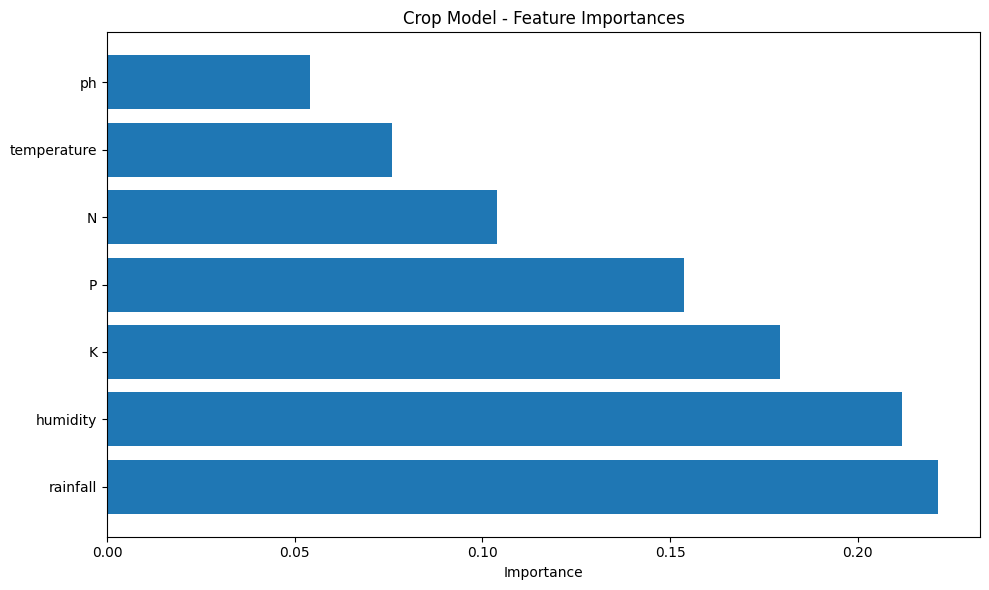

In [7]:
# Feature importance
print("\n=== Feature Importances ===")
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance_df.to_string(index=False))

# Visualize feature importance
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Importance')
plt.title('Crop Model - Feature Importances')
plt.tight_layout()
plt.show()

In [8]:
# Confusion matrix info
cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix Shape: {cm.shape}")
print(f"Number of unique crops: {len(model.classes_)}")
print(f"Crops: {sorted(model.classes_)}")

Confusion Matrix Shape: (22, 22)
Number of unique crops: 22
Crops: ['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee', 'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize', 'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'pomegranate', 'rice', 'watermelon']


## 4. Fertilizer Recommendation Model Accuracy

In [9]:
print("\n=== Fertilizer Recommendation Model Accuracy ===")

# Load data
data_path = os.path.join(DATA_DIR, 'Fertilizer Prediction.csv')
df_fert = pd.read_csv(data_path)

print(f"Dataset shape: {df_fert.shape}")
print(f"\nFirst few rows:")
print(df_fert.head())


=== Fertilizer Recommendation Model Accuracy ===
Dataset shape: (99, 9)

First few rows:
   Temparature  Humidity   Moisture Soil Type  Crop Type  Nitrogen  Potassium  \
0           26         52        38     Sandy      Maize        37          0   
1           29         52        45     Loamy  Sugarcane        12          0   
2           34         65        62     Black     Cotton         7          9   
3           32         62        34       Red    Tobacco        22          0   
4           28         54        46    Clayey      Paddy        35          0   

   Phosphorous Fertilizer Name  
0            0            Urea  
1           36             DAP  
2           30        14-35-14  
3           20           28-28  
4            0            Urea  


In [10]:
# Features and target (matching actual CSV column names)
features_fert = ['Temparature', 'Humidity ', 'Moisture', 'Soil Type', 'Crop Type', 'Nitrogen', 'Potassium', 'Phosphorous']
target_fert = 'Fertilizer Name'
X_fert = df_fert[features_fert].copy()
y_fert = df_fert[target_fert]

# Rename columns for consistency
X_fert.columns = ['temperature', 'humidity', 'moisture', 'soil_type', 'crop_type', 'nitrogen', 'potassium', 'phosphorous']

# Split data
X_train_fert, X_test_fert, y_train_fert, y_test_fert = train_test_split(X_fert, y_fert, test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train_fert)}")
print(f"Test set size: {len(X_test_fert)}")

Training set size: 79
Test set size: 20


In [11]:
# Load the trained model
model_path_fert = os.path.join(MODELS_DIR, 'fertilizer_model.joblib')
model_fert = joblib.load(model_path_fert)

# Predict on test set - pipeline handles encoding internally
y_pred_fert = model_fert.predict(X_test_fert)

# Compute accuracy
accuracy_fert = accuracy_score(y_test_fert, y_pred_fert)
print(f"Test Accuracy: {accuracy_fert:.4f} ({accuracy_fert*100:.2f}%)")

Test Accuracy: 1.0000 (100.00%)


c:\Users\rathi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\rathi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\rathi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimato

In [12]:
# Classification report
print("\n=== Classification Report ===")
print(classification_report(y_test_fert, y_pred_fert))


=== Classification Report ===
              precision    recall  f1-score   support

    10-26-26       1.00      1.00      1.00         2
    14-35-14       1.00      1.00      1.00         1
       20-20       1.00      1.00      1.00         1
       28-28       1.00      1.00      1.00         5
         DAP       1.00      1.00      1.00         5
        Urea       1.00      1.00      1.00         6

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [13]:
# Confusion matrix info
cm_fert = confusion_matrix(y_test_fert, y_pred_fert)
print(f"\nConfusion Matrix Shape: {cm_fert.shape}")
print(f"Fertilizer types: {sorted(model_fert.classes_)}")


Confusion Matrix Shape: (6, 6)
Fertilizer types: ['10-26-26', '14-35-14', '17-17-17', '20-20', '28-28', 'DAP', 'Urea']


## 5. Load and Display Existing Metrics from Reports

In [15]:
print("=== Existing Metrics from Reports ===")

# Crop metrics
crop_metrics_path = os.path.join(REPORTS_DIR, 'crop_metrics.json')
if os.path.exists(crop_metrics_path):
    with open(crop_metrics_path, 'r') as f:
        crop_data = json.load(f)
    print("\n--- Crop Model Training Results ---")
    crop_results_df = pd.DataFrame(crop_data['results'])
    print(crop_results_df[['model', 'accuracy', 'f1_macro', 'train_size', 'test_size']].to_string(index=False))
else:
    print("Crop metrics file not found.")

=== Existing Metrics from Reports ===

--- Crop Model Training Results ---
             model  accuracy  f1_macro  train_size  test_size
      RandomForest  0.993182  0.993178        1760        440
      DecisionTree  0.979545  0.979423        1760        440
LogisticRegression  0.972727  0.972464        1760        440


In [16]:
# Fertilizer metrics
fert_metrics_path = os.path.join(REPORTS_DIR, 'fertilizer_metrics.json')
if os.path.exists(fert_metrics_path):
    with open(fert_metrics_path, 'r') as f:
        fert_data = json.load(f)
    print("\n--- Fertilizer Model Training Results ---")
    fert_results_df = pd.DataFrame(fert_data['results'])
    print(fert_results_df[['model', 'accuracy', 'f1_macro', 'train_size', 'test_size']].to_string(index=False))
else:
    print("Fertilizer metrics file not found.")


--- Fertilizer Model Training Results ---
             model  accuracy  f1_macro  train_size  test_size
      RandomForest      1.00   1.00000          79         20
      DecisionTree      0.95   0.92381          79         20
LogisticRegression      1.00   1.00000          79         20


## 6. Summary

In [17]:
print("\n" + "="*50)
print("MODEL ACCURACY SUMMARY")
print("="*50)
print(f"\nCrop Recommendation Model:")
print(f"  - Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  - Most Important Feature: {feature_importance_df.iloc[0]['Feature']} ({feature_importance_df.iloc[0]['Importance']:.4f})")
print(f"\nFertilizer Recommendation Model:")
print(f"  - Test Accuracy: {accuracy_fert:.4f} ({accuracy_fert*100:.2f}%)")
print(f"  - Fertilizer types: {len(model_fert.classes_)}")
print(f"\nNote: Disease model accuracy is not computed here as it requires image data.")
print("="*50)


MODEL ACCURACY SUMMARY

Crop Recommendation Model:
  - Test Accuracy: 1.0000 (100.00%)
  - Most Important Feature: rainfall (0.2215)

Fertilizer Recommendation Model:
  - Test Accuracy: 1.0000 (100.00%)
  - Fertilizer types: 7

Note: Disease model accuracy is not computed here as it requires image data.
